# Modelling the generic power curve as a function of rotor area and nominal power as well as environmental chararcteristics 


A wind turbine’s power curve relates its power production to the wind speed it experiences. The typical
shape of a power curve is well known and has been studied extensively; however, the power curves of
individual turbine models can vary widely from one another. This is due to both the technical features of
the turbine (power density, cut-in and cut-out speeds, limits on rotational speed and aerodynamic efficiency),
and environmental factors (turbulence intensity, air density, wind shear and wind veer). Data on individual
power curves are often proprietary and only available through commercial databases.
We therefore develop an open-source model which can generate the power curve of any turbine, adapted
to the specific conditions of any site. This can employ one of six parametric models advanced in the
literature, and accounts for the eleven variables mentioned above. 

Yves-Marie Saint-Drenan, Romain Besseau, Malte Jansen, Iain Staffell, Alberto Troccoli, Laurent Dubus, Johannes Schmidt, Katharina Gruber, Sofia G. Simões, Siegfried Heier, A parametric model for wind turbine power curves incorporating environmental conditions, Renewable Energy,,Volume 157,2020,Pages 754-768,ISSN 0960-1481,
https://doi.org/10.1016/j.renene.2020.04.123.

List of changes since the publication:
 - add of a constant Cp function
 - integration of a conversion efficiency factor to account for different non-aerodynamic losses


In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
matplotlib.rcParams['figure.figsize'] = (10, 5)

## Parametric model of the power coefficient C$_p$(λ, β)

In [2]:
def CpLambdaModels(Model,TSR,Beta=[]):
    
    #vSources=['Slootweg et al. 2003','Heier 2009','Thongam et al. 2009','De Kooning et al.  2010','Ochieng et Manyonge 2014','Dai et al. 2016','constant']
    
    TSR=np.maximum(0.0001,TSR)
    
    if Beta==[]:
        Beta=np.zeros(TSR.shape)
    if Model=='constant':
        Cp=np.ones(TSR.shape)*0.49
    else:
        if Model=='Slootweg et al. 2003':
            c1,c2,c3,c4,c5,c6,c7,c8,c9,c10=0.73,151,0.58,0,0.002,13.2,18.4,0,-0.02,0.003
            x=2.14
        elif  Model=='Heier 2009':
            c1,c2,c3,c4,c5,c6,c7,c8,c9,c10=0.5,116,0.4,0,0,5,21,0,0.089,0.035
            x=0
        elif  Model=='Thongam et al. 2009':
            c1,c2,c3,c4,c5,c6,c7,c8,c9,c10=0.5176,116,0.4,0,0,5,21,0.006795,0.089,0.035
            x=0
        elif  Model=='De Kooning et al. 2010':
            c1,c2,c3,c4,c5,c6,c7,c8,c9,c10=0.77,151,0,0,0,13.65,18.4,0,0,0
            x=0
        elif  Model=='Ochieng et Manyonge 2014':
            c1,c2,c3,c4,c5,c6,c7,c8,c9,c10=0.5,116,0,0.4,0,5,21,0,0.08,0.035
            x=0
        elif  Model=='Dai et al. 2016':
            c1,c2,c3,c4,c5,c6,c7,c8,c9,c10=0.22,120,0.4,0,0,5,12.5,0,0.08,0.035
            x=0

        Li=1/(1/(TSR+c9*Beta)-c10/(Beta**3+1));
        Cp=np.maximum(0,c1*(c2/Li-c3*Beta-c4*Li*Beta-c5*Beta**x-c6)*np.exp(-c7/Li)+c8*TSR);
    
    return Cp

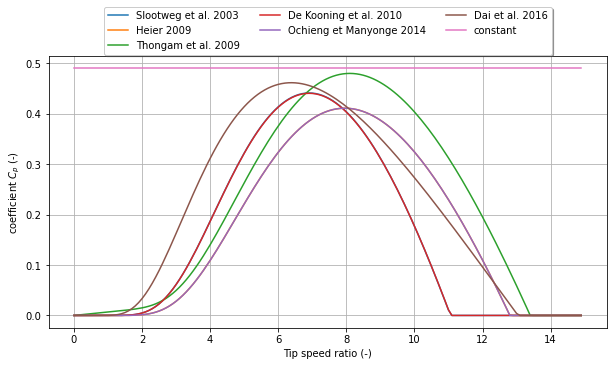

In [3]:
TSR=np.arange(0,15,0.1)
for Model in ['Slootweg et al. 2003','Heier 2009','Thongam et al. 2009','De Kooning et al. 2010','Ochieng et Manyonge 2014','Dai et al. 2016','constant']:
    Cp=CpLambdaModels(Model,TSR,Beta=[])
    plt.plot(TSR,Cp,label=Model)    
plt.xlabel('Tip speed ratio (-)')
plt.ylabel('coefficient $C_p$ (-)')
plt.grid()
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2),fancybox=True, shadow=True, ncol=3)

## Calculation of the wind turbine curve without environmental effect

In [4]:
def WT_PowerCurve_raw(Vws,Pnom,Drotor,rMin=[],rMax=[],CpMax=[],Model='Dai et al. 2016',Beta=[],AirDensity=1.225,ConvEff=0.92):

    Rrotor = Drotor/2
    Arotor = np.pi*Rrotor**2

    # ********************************************************************************************
    # 1) Parameterisation of the minimal and maximal rotor rotational speed as a
    # function of the rotor diameter + calculation of VtipMin & VtipMax
    # source: http://publications.lib.chalmers.se/records/fulltext/179591/179591.pdf
    # ********************************************************************************************
    if rMin==[]:
        rMin=188.8*Drotor**(-0.7081)   # minimal angular speed in rpm
    if rMax==[]:
        rMax=793.7*Drotor**(-0.8504);      # maximal angular speed in rpm
    VtipMin=rMin*(2*np.pi*Rrotor)/60   # minimal tip speed in m/s
    VtipMax=rMax*(2*np.pi*Rrotor)/60  # maximal tip speed in m/s
    
    # ********************************************************************************************
    # 2) Calculation of the tip speed as a function of the wind speed 
    # ********************************************************************************************
    # In ths calculation step, the following assumptions are made:
    # a) the tip speed is set to maximize the energy output (*),
    #    which is achieved by setting lambda to lambdaopt, 
    # b) and assuming that Vtip is always comprised between VtipMin and VtipMax (**)
    # c) using an expression of cp as a function of lambda from (***) (no pitch control
    # assumed (**))
    # Sources:
    # (*) http://mstudioblackboard.tudelft.nl/duwind/Wind%20energy%20online%20reader/Static_pages/Cp_lamda_curve.htm
    # (**) http://www.mdpi.com/1996-1073/10/3/395
    # (***)http://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=6699403

    # Calculation of the optimal tip speed ratio and maximal power coefficient
    vTSR=np.arange(0,12,0.001)
    vCp=CpLambdaModels(Model,vTSR,Beta)
    TSR_Opt=np.mean(vTSR[vCp==max(vCp)])
    
    # scaling of the power coefficient function if a value is given for CpMax
    if CpMax==[]:
        CpScale=1
        CpMax=max(vCp)
    else:
        CpScale=CpMax/max(vCp)
    
    # Calculation of the tip speed and the tip speed ratio
    Vtip=np.minimum(VtipMax,np.maximum(VtipMin,TSR_Opt*Vws))
    TSR=np.zeros(Vws.shape)
    TSR[Vws>0]=Vtip[Vws>0]/Vws[Vws>0]
        
    # Calculation of the power coefficient
    Cp0=np.maximum(0,ConvEff*CpScale*CpLambdaModels(Model,TSR))

    # Calculation of the input power as a function of air density, wind speed and rotor area
    Pin=0.5*AirDensity*Arotor*(Vws**3)/1000
    Cp=np.zeros(Pin.shape)
    Cp[Pin>0]=np.minimum(Cp0[Pin>0],Pnom/Pin[Pin>0])
    Pout = Cp*Pin

    return Pout

Text(0.5, 1.0, 'Power curve calculated for a wind turbine  with a nominal \n power of 14.7 MW and a rotor diameter of 220 m \n (without consideration of environmental effects and Vcutin/Vcutout)')

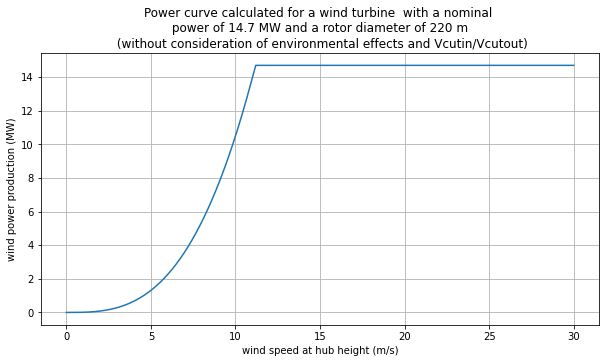

In [5]:
rMin    = 4
rMax    = 13
Drotor  = 220
Pnom    = 14700
Vws     = np.arange(0,30,0.01)

Pwt=WT_PowerCurve_raw(Vws,Pnom,Drotor,rMin=[],rMax=[],CpMax=[],Model='constant',AirDensity=1.225)
plt.plot(Vws,Pwt/1000)
plt.grid()
plt.xlabel('wind speed at hub height (m/s)')
plt.ylabel('wind power production (MW)')
plt.title('Power curve calculated for a wind turbine  with a nominal \n power of {} MW and a rotor diameter of {} m \n (without consideration of environmental effects and Vcutin/Vcutout)'.format(Pnom/1000,Drotor))

## Consideration of the environmental effects

### Turbulence intensity

In [6]:
def calcEffectTI(Vws,Pwt,TI=0.05,Vcutin=3,Vcutoff=34):
    
    #Gaussian filter over w*(1-TI):w*(1+TI), TI being the turbulence intensity
    if TI>0:
        Pwt_ti=0*np.ones(Vws.shape)
        for iws,tWS in enumerate(Vws):
            sigma=TI*tWS
            ix=np.where((Vws>(tWS-5*sigma)) & (Vws<(tWS+5*sigma)))[0]
            weight=np.exp(-0.5*(((Vws[ix]-tWS)/sigma)**2))
            if sum(weight)>0:
                Pwt_ti[iws]=sum(Pwt[ix]*weight)/sum(weight)
    else:
        Pwt_ti=Pwt

    # Setting the power production to zero below the cut-in and above the cut-off wind speeds
    Pwt_ti[Vws<Vcutin]=0
    Pwt_ti[Vws>Vcutoff]=0
    return Pwt_ti

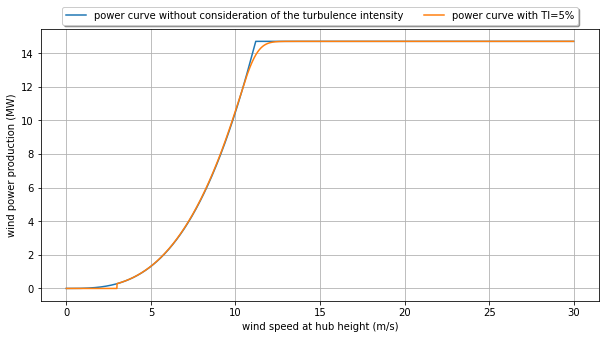

In [7]:
Pwt_ti=calcEffectTI(Vws,Pwt,TI=0.05,Vcutin=3,Vcutoff=34)

plt.plot(Vws,Pwt/1000,label='power curve without consideration of the turbulence intensity')
plt.plot(Vws,Pwt_ti/1000,label='power curve with TI=5%')
plt.grid()
plt.xlabel('wind speed at hub height (m/s)')
plt.ylabel('wind power production (MW)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1),fancybox=True, shadow=True, ncol=2)

### Wind shear and veer: calculation of the rotor equivalent wind speed (REWS)


#### wind shear: wind speed variation with height

Wind speed is not uniform across the wind turbine's rotor plane, as it increases with height through
the atmospheric boundary layer. The vertical wind prole can be described in several ways (Schallenberg-
Rodriguez, 2013), such as the logarithmic prole which depends on the roughness length, friction velocity
and stability parameter. In many applications, the simpler power law model is used which relates the ratio
of the wind speeds at two heights with the power of the ratio of the two heights:

$u(z_i)=u(z_{hub}).(z_i/z_{hub})^{\alpha}$

where $\alpha$ is the adimensional wind shear.

#### wind veer: wind direction variation with height

Wind veer is dened as the change in wind direction as a function of height. It has been shown that
wind veer does exist in typical wind situations (Ivanell et al., 2010). To consider wind veer, we assume that the change in wind direction is zero at hub height and varies linearly with height according to:

$\Delta \phi(z_i)=v.(z_i-z_{hub})$

where $v$ is the wind veer expressed in degree/meters

#### rotor equivalent wind speed (REWS)

To evaluate the impact of wind shear and veer on the power curve, we follow the approach that is
recommended in a revision of the IEC standard (CDV IEC 61400-12-1, Ed. 2, 2015), which consists in
replacing the wind speed at hub height by a rotor equivalent wind speed Ueq, which is defined as:

$U_{eq}=^3\sqrt(\sum_i((A_i/A).(U_.cos(\Delta \phi(z_i)))))^3$

https://www.windguard.com/publications-wind-energy-statistics.html?file=files/cto_layout/img/unternehmen/veroeffentlichungen/2016/Power%20Curve%20Uncertainty%20of%20Rotor%20Equivalent%20Wind%20Speed.pdf

In [8]:
def calcREWS(Vws,zhub,Drotor,Shear,Veer):
    N=10000
    zi=zhub+np.linspace(-Drotor/2,Drotor/2,N)
    dz=Drotor/N
    Ai=(2*np.sqrt((Drotor/2)**2-(zi-zhub)**2))*dz
    A=np.sum(Ai)
    
    CoeffShear=(zi/zhub)**Shear
    CoeffVeer=np.cos((zi-zhub)*Veer*np.pi/180)

    REWS=np.ones(Vws.shape)*np.nan
    for ii,V in enumerate(Vws):
        Vi=V*CoeffShear*CoeffVeer
        REWS[ii]=(np.sum((Vi**3)*Ai/A))**(1/3)
    
    return REWS

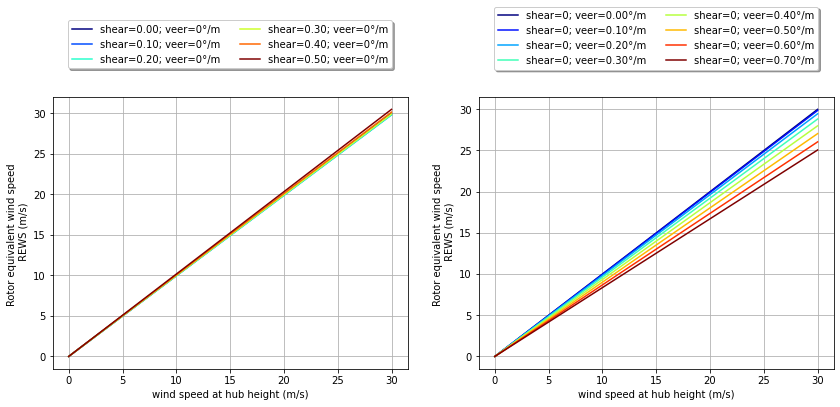

In [9]:
vShear=np.arange(0,0.6,0.1)
vVeer=np.arange(0,0.8,0.1)

Drotor = 220
zhub   = 150
Vws    = np.arange(0,30,0.01)

fig,axs=plt.subplots(1,2,figsize=(14, 5))

norm = matplotlib.colors.Normalize(vmin=min(vShear), vmax=max(vShear))
for Shear in vShear:
    rgba_color = np.array(cm.jet(norm(Shear),bytes=True))/255
    REWS=calcREWS(Vws,zhub,Drotor,Shear,Veer=0)
    axs[0].plot(Vws,REWS,label='shear={0:.2f}; veer=0°/m'.format(Shear),color=rgba_color)
axs[0].grid()
axs[0].set_xlabel('wind speed at hub height (m/s)')
axs[0].set_ylabel('Rotor equivalent wind speed \n REWS (m/s)')
axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.3),fancybox=True, shadow=True, ncol=2)

norm = matplotlib.colors.Normalize(vmin=min(vVeer), vmax=max(vVeer))
for Veer in vVeer:
    rgba_color = np.array(cm.jet(norm(Veer),bytes=True))/255
    REWS=calcREWS(Vws,zhub,Drotor,Shear=0,Veer=Veer)
    axs[1].plot(Vws,REWS,label='shear=0; veer={0:.2f}°/m'.format(Veer),color=rgba_color)

axs[1].grid()
axs[1].set_xlabel('wind speed at hub height (m/s)')
axs[1].set_ylabel('Rotor equivalent wind speed \n REWS (m/s)')
axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35),fancybox=True, shadow=True, ncol=2)

## Putting everything together

In [10]:
def GenericWindTurbinePowerCurve(Vws,Pnom,Drotor,zhub=[],Vcutin=3,Vcutoff=34,TI=0.1,Shear=0.15,Veer=0,rMin=[],rMax=[],CpMax=[],Model='Dai et al. 2016',Beta=[],AirDensity=1.225,ConvEff=[]):
    
    # conversion losses
    if ConvEff==[]:
        gear_loss_const= .01
        gear_loss_var= .014
        generator_loss= 0.03
        converter_loss= .03
        ConvEff=(1-gear_loss_const)*(1-gear_loss_var)*(1-generator_loss)*(1-converter_loss)
    
    # Estimation of the hub height based on a statistical relationship made using data from thewindpower.net
    if zhub==[]:
        zhub=150
        
    # Calculation of the rotor equivalent wind speed
    REWS=calcREWS(Vws,zhub,Drotor,Shear,Veer)

    # Calculation of the power curve without consideration of the TI and cut-in and cut-off wind speeds
    Pout_raw=WT_PowerCurve_raw(REWS,Pnom,Drotor,rMin,rMax,CpMax,Model,Beta,AirDensity,ConvEff)

    # Calculation of the effect of the TI, cut-in and cut-off wind speeds on the power curve
    Pwt_ti=calcEffectTI(REWS,Pout_raw,TI,Vcutin,Vcutoff)
   
    return Pwt_ti

The different functions described in this notebook are included in the library "GenericWindTurbinePowerCurve.py". The following example shows that a power curve can be estimated with a very limited number of characteristics (nominal power, rotor diameter)

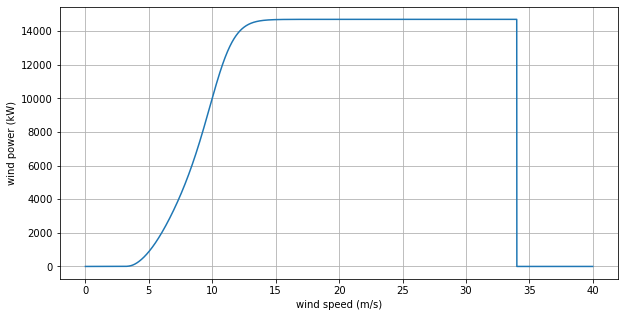

In [25]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 5)
import GenericWindTurbinePowerCurve as GWTPC

Pnom    = 14700                 #power rating kW
Drotor  = 220                   #rotor diameter
Vws     = np.arange(0,40,0.01) #velocity range

Pwt=GWTPC.GenericWindTurbinePowerCurve(Vws,Pnom,Drotor,Vcutin=3,Vcutoff=34,TI=0.1)

plt.figure()
plt.ion()
plt.plot(Vws,Pwt)
plt.ylabel('wind power (kW)')
plt.xlabel('wind speed (m/s)')
plt.grid()
plt.show()

In [32]:
for i in range(36):
    print(f'x={i}, y={np.interp(i,Vws,Pwt)}')

x=0, y=0.0
x=1, y=0.0
x=2, y=0.0
x=3, y=0.0
x=4, y=184.60516805666077
x=5, y=880.1247883654071
x=6, y=1984.9631448951543
x=7, y=3422.751885201847
x=8, y=5193.748698710186
x=9, y=7405.092821477549
x=10, y=10019.845706254977
x=11, y=12412.978961691226
x=12, y=13859.161866809043
x=13, y=14452.160678217144
x=14, y=14636.49917653438
x=15, y=14684.864651053433
x=16, y=14696.476369985692
x=17, y=14699.172886200751
x=18, y=14699.800849246965
x=19, y=14699.950917081684
x=20, y=14699.988020327999
x=21, y=14699.99740140203
x=22, y=14699.99968827114
x=23, y=14699.999999999922
x=24, y=14699.999999999998
x=25, y=14699.99999999999
x=26, y=14700.000000000033
x=27, y=14699.99999999998
x=28, y=14699.99999999994
x=29, y=14700.000000000011
x=30, y=14699.999999999993
x=31, y=14700.000000000004
x=32, y=14699.999999999995
x=33, y=14699.999999999996
x=34, y=14699.999999999989
x=35, y=0.0
